# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# Plan y estructura del notebook
Este notebook está organizado en secciones para entender paso a paso cómo construir un modelo de regresión lineal para predecir la progresión de la diabetes:

1. Exploración de datos: entender dimensiones, estadísticas y relaciones.
2. Preparación de datos: seleccionar características, dividir en entrenamiento/prueba y escalado si es necesario.
3. Entrenamiento del modelo: ajustar un modelo de regresión lineal con scikit-learn.
4. Evaluación: métricas (MSE, RMSE, R2) y visualizaciones (predicho vs real).
5. Interpretación: inspeccionar coeficientes para ver la influencia de cada variable.
6. Siguientes pasos: ideas para mejorar el modelo.

# 1) Exploración de datos
En esta sección revisamos la forma del dataset, estadísticas resumidas y visualizamos correlaciones para identificar relaciones entre variables y la variable objetivo.

Dimensiones (filas, columnas): (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Valores nulos por columna:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


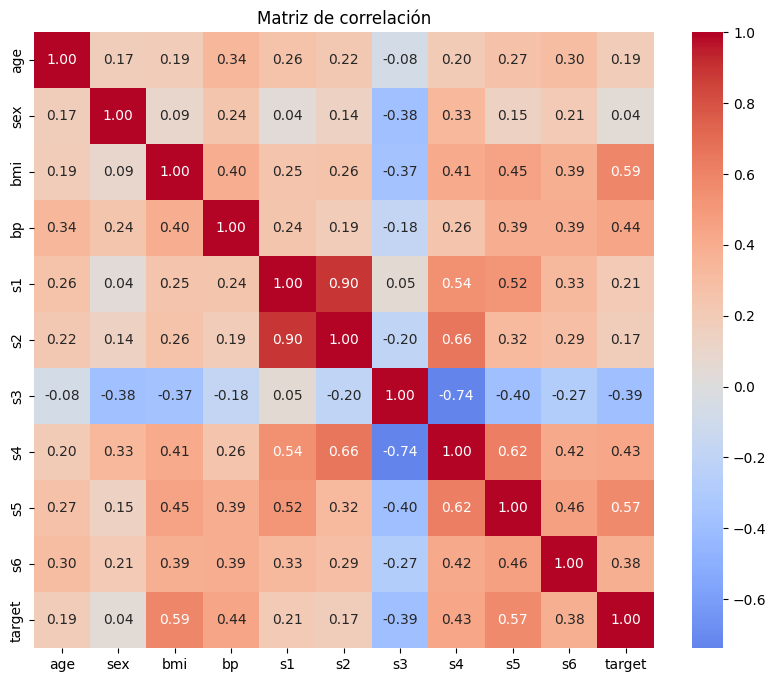


Variables más correlacionadas con la target:
 target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s3        0.394789
Name: target, dtype: float64


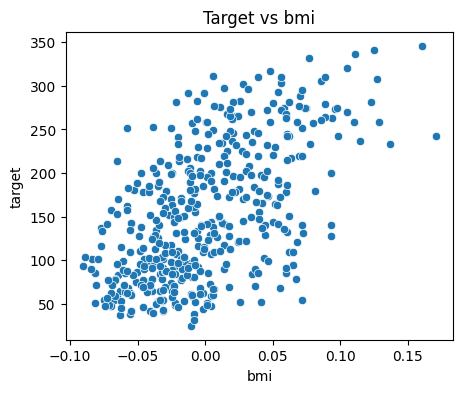

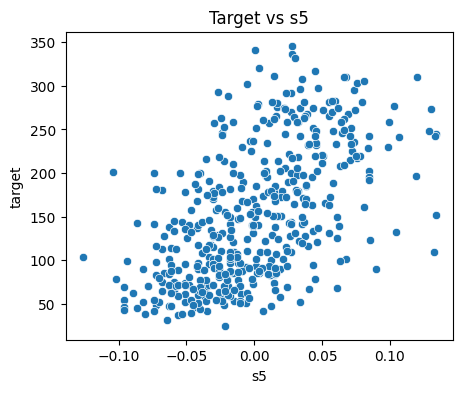

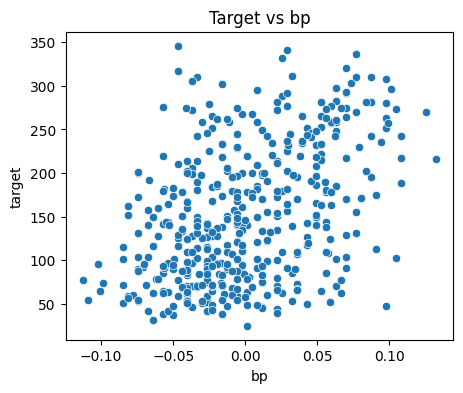

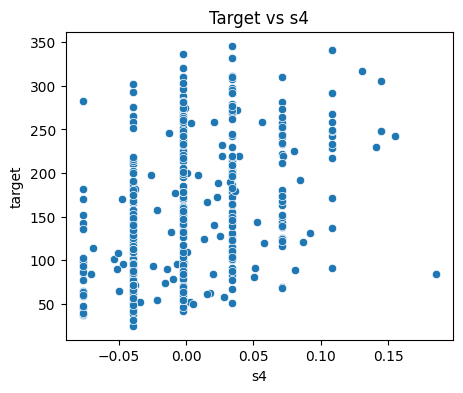

In [6]:
# Exploración de datos
import seaborn as sns
from IPython.display import display

# Tamaño del dataset y primeras filas
print("Dimensiones (filas, columnas):", df.shape)
display(df.head())

# Estadísticas descriptivas
display(df.describe())

# Revisar si hay valores nulos
print("Valores nulos por columna:\n", df.isnull().sum())

# Matriz de correlación (incluye la variable objetivo)
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

# Visualizar relación entre las 4 variables más correlacionadas con la target
corr_target = corr['target'].abs().sort_values(ascending=False)
print('\nVariables más correlacionadas con la target:\n', corr_target.head(6))

top_feats = corr_target.index[1:5].tolist()  # excluir 'target' y tomar las 4 siguientes
for feat in top_feats:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[feat], y=df['target'])
    plt.title(f'Target vs {feat}')
    plt.xlabel(feat)
    plt.ylabel('target')
    plt.show()

# 2) Preparación de datos
Aquí separamos características y objetivo, dividimos en conjuntos de entrenamiento y prueba y opcionalmente escalamos los datos. Nota: el dataset de diabetes ya viene estandarizado, pero muestro cómo hacerlo si fuera necesario.

In [8]:
# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target']).values
y = df['target'].values

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Tamaños: X_train={}, X_test={}'.format(X_train.shape, X_test.shape))

# Escalado (opcional - mostrar cómo) -- comentar si no se desea
scaler = StandardScaler()
# En este dataset las features ya están estandarizadas, pero si provienen de otra fuente descomentar:
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

Tamaños: X_train=(353, 10), X_test=(89, 10)


# 3) Entrenamiento del modelo
Ajustamos un modelo de Regresión Lineal simple usando scikit-learn.

In [9]:
# Entrenamiento del modelo
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print('Entrenamiento completado')

Entrenamiento completado


# 4) Evaluación del modelo
Calculamos métricas de regresión (MSE, RMSE, R^2) y visualizamos predicciones vs valores reales.

MSE train: 2868.55
MSE test: 2900.19
RMSE test: 53.85
R^2 test: 0.453


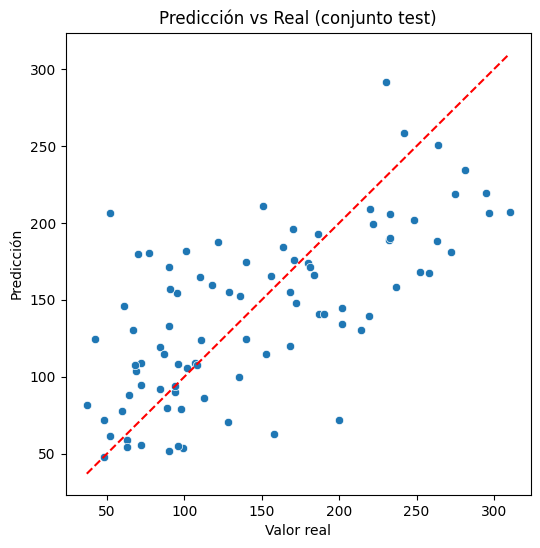

In [10]:
# Evaluación
from sklearn.metrics import mean_squared_error, r2_score

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')
print(f'RMSE test: {rmse_test:.2f}')
print(f'R^2 test: {r2_test:.3f}')

# Gráfica: predicho vs real (test)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Predicción vs Real (conjunto test)')
plt.show()

# 5) Interpretación de coeficientes
La regresión lineal es lineal en los parámetros; los coeficientes nos indican la dirección y magnitud del efecto de cada variable en la predicción (manteniendo las demás constantes).

In [11]:
# Interpretación de coeficientes
feature_names = df.drop(columns=['target']).columns.tolist()
coefs = model.coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False).drop(columns=['abs_coef'])

display(coef_df)

print('\nInterpretación rápida:')
for _, row in coef_df.head(5).iterrows():
    sign = 'positivo' if row['coefficient'] > 0 else 'negativo'
    print(f"- {row['feature']}: coeficiente {row['coefficient']:.3f} ({sign}) -> mayor impacto relativo")

,feature,coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021



Interpretación rápida:
- s1: coeficiente -931.489 (negativo) -> mayor impacto relativo
- s5: coeficiente 736.199 (positivo) -> mayor impacto relativo
- bmi: coeficiente 542.429 (positivo) -> mayor impacto relativo
- s2: coeficiente 518.062 (positivo) -> mayor impacto relativo
- bp: coeficiente 347.704 (positivo) -> mayor impacto relativo
